In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pythtb import TBModel, Lattice

## Lien vers les CSV

In [10]:
# Fractal étudié
coords_path = "../files/csv/sirpenski_triangle-equi-hetero_points.csv"
edges_path = "../files/csv/sirpenski_triangle-equi-hetero_edges.csv"
use_t = True

# Référence régulière pour le papillon de Hofstadter (seule la géométrie est utilisée, t = 1)
ref_coords_path = "../files/csv/sirpenski_triangle-equi_points.csv"
ref_edges_path = "../files/csv/sirpenski_triangle-equi_edges.csv"

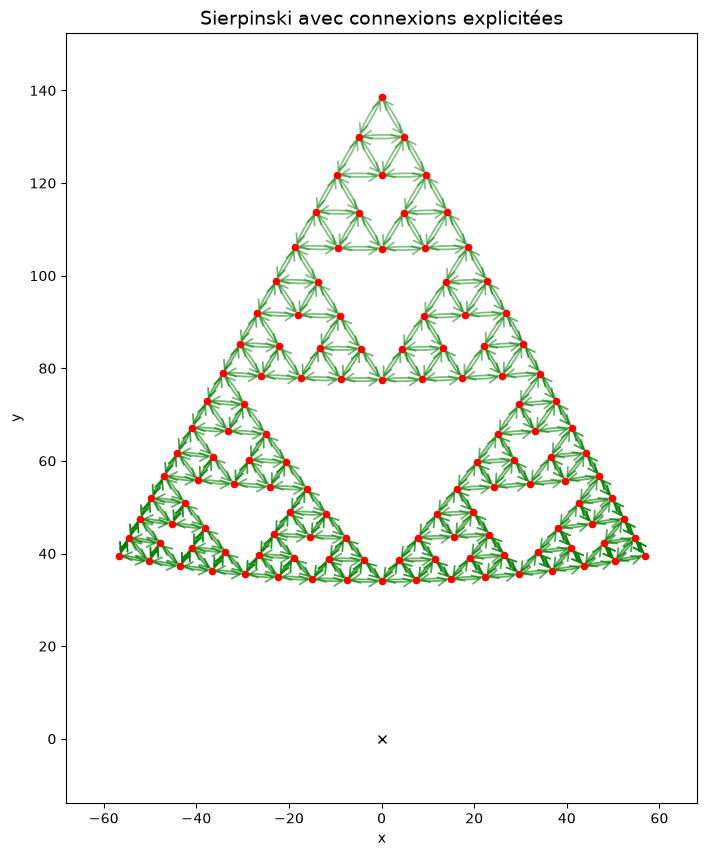

In [11]:
df = pd.read_csv(coords_path, sep=',', decimal='.')
coords = df[['x', 'y']].to_numpy()

df = pd.read_csv(edges_path, sep=',', decimal='.')
if use_t:
    edges = df[['i', 'j', 't']].to_numpy()
    # t relatifs à la liaison médiane (t = 1), comme à l'export : corrige les anciens CSV
    t_median = np.median(edges[:, 2])
    if not np.isclose(t_median, 1.0):
        print(f"t renormalisés : médiane {t_median:.3g} -> 1")
        edges[:, 2] /= t_median
else:
    edges = df[['i', 'j']].to_numpy()

# 3. Création du réseau non-périodique
# np.eye(2) = matrice identité de taille 2 => plan orthonormée
lat = Lattice(np.eye(2), coords, periodic_dirs=[])
model = TBModel(lat)

# 4. Paramètres
t_ = -1.0
model.set_onsite([0.0] * len(coords))

# 5. Ajout direct des liaisons depuis le tableau 'edges'
if use_t:
    for i, j, t in edges:
        model.set_hop(t_ * t, int(i), int(j)) # attention le cast en int ajoute de l'incertitude
else:
    for i, j in edges:
        model.set_hop(t_, int(i), int(j)) # attention le cast en int ajoute de l'incertitude

# 6. Affichage
fig, ax = model.visualize()
fig.set_size_inches(12, 10)  # Remplacez 12, 10 par les dimensions souhaitées
plt.title("Sierpinski avec connexions explicitées", fontsize=14)
plt.show()

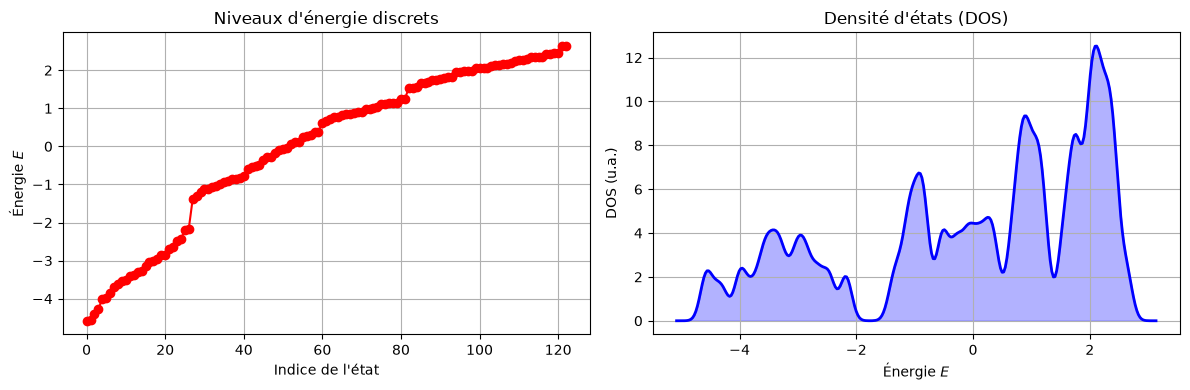

In [12]:
# 1. Calcul des niveaux d'énergie discrets (15 valeurs propres)
evals = model.solve_ham()

# 2. Plot A : Niveaux d'énergie discrets (l'équivalent des "bandes" pour un fractal)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Graphique des valeurs propres
ax1.plot(evals, 'ro-', markersize=6, linewidth=1.5)
ax1.set_title("Niveaux d'énergie discrets")
ax1.set_xlabel("Indice de l'état")
ax1.set_ylabel("Énergie $E$")
ax1.grid(True)

# 3. Plot B : Densité d'états (DOS) lissée
energies = np.linspace(min(evals) - 0.5, max(evals) + 0.5, 300)
sigma = 0.1  # Élargissement gaussien
dos = np.sum([np.exp(-((energies - e) ** 2) / (2 * sigma ** 2)) for e in evals], axis=0)

ax2.plot(energies, dos, 'b-', linewidth=2)
ax2.fill_between(energies, 0, dos, alpha=0.3, color='b')
ax2.set_title("Densité d'états (DOS)")
ax2.set_xlabel("Énergie $E$")
ax2.set_ylabel("DOS (u.a.)")
ax2.grid(True)

plt.tight_layout()
plt.show()

## États propres et localisation

L'**IPR** (*inverse participation ratio*) $\sum_i |\psi_n(i)|^4$ mesure sur combien de sites vit un état : $1/N$ s'il est réparti uniformément sur les $N$ sites, $1$ s'il est concentré sur un seul.
Sur une fractale, on s'attend à des états localisés sur des motifs précis (coins, sous-triangles) imposés par la géométrie, ce qu'un cristal n'a pas.

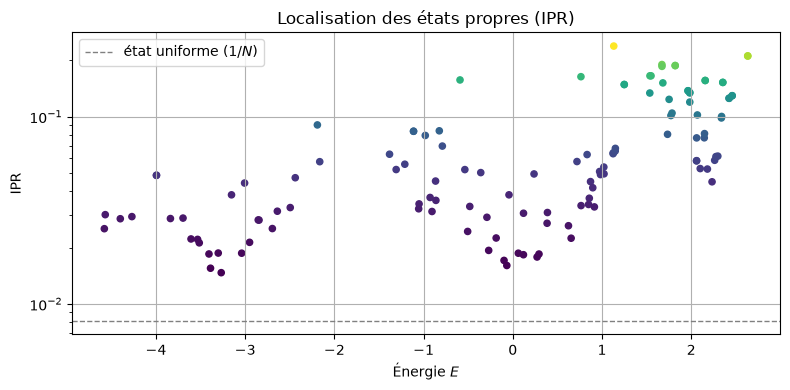

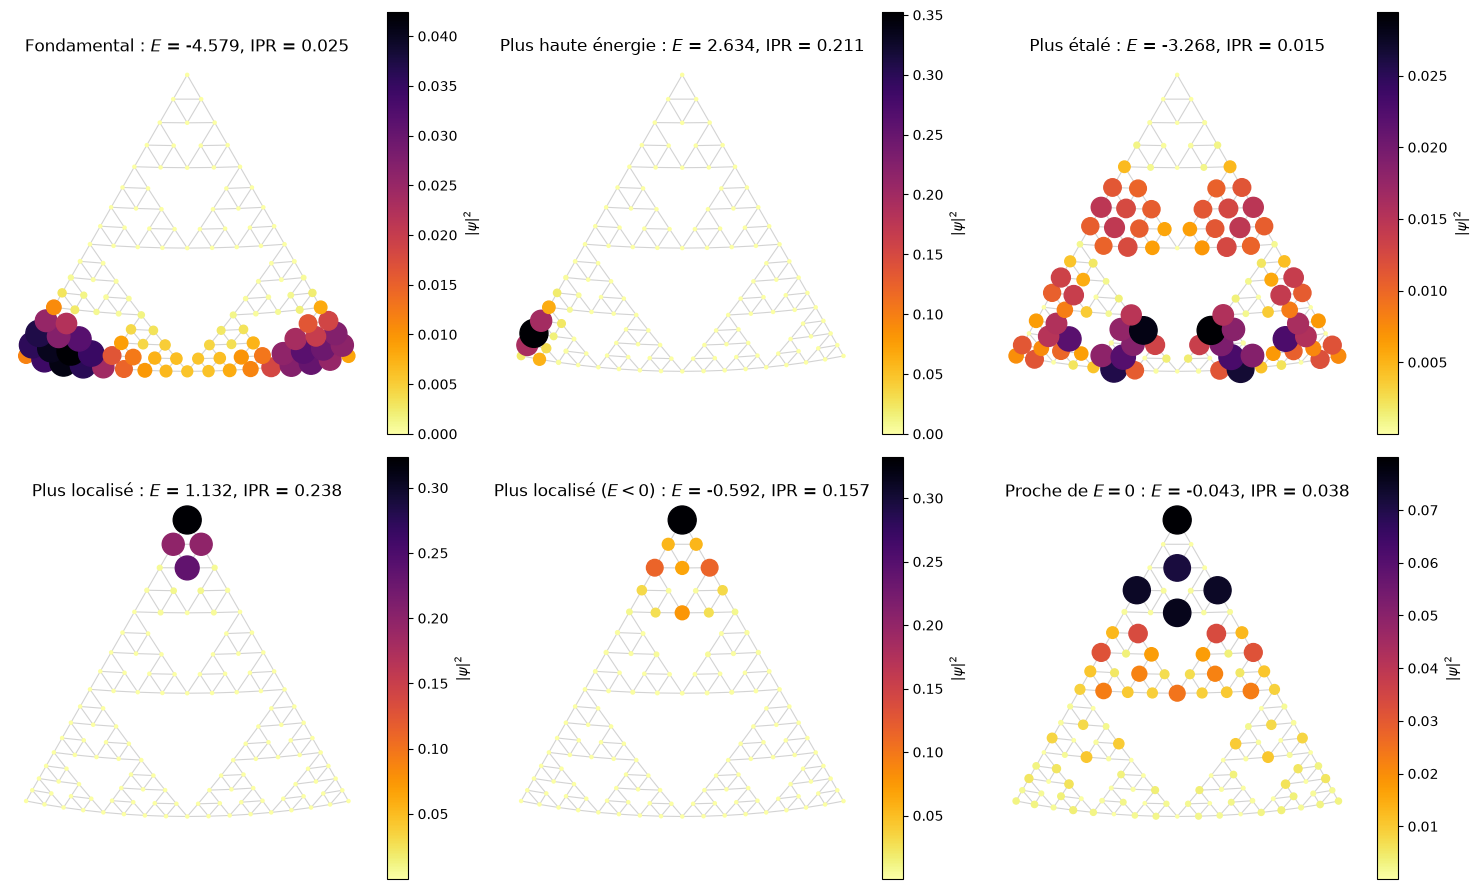

In [13]:
# 1. Diagonalisation avec les vecteurs propres
evals, evecs = model.solve_ham(return_eigvecs=True)
evecs = np.asarray(evecs).reshape(len(evals), len(coords))
prob = np.abs(evecs) ** 2  # |ψ_n(i)|², chaque ligne somme à 1

# 2. IPR : 1/N pour un état étalé sur les N sites, 1 pour un état sur un seul site
ipr = np.sum(prob ** 2, axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
sc = ax.scatter(evals, ipr, c=ipr, cmap="viridis", s=20)
ax.axhline(1 / len(coords), color="gray", linestyle="--", linewidth=1, label="état uniforme ($1/N$)")
ax.set_yscale("log")
ax.set_title("Localisation des états propres (IPR)")
ax.set_xlabel("Énergie $E$")
ax.set_ylabel("IPR")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# 3. Carte de |ψ|² pour quelques états représentatifs
order = np.argsort(ipr)
selected = {
    "Fondamental": 0,
    "Plus haute énergie": len(evals) - 1,
    "Plus étalé": order[0],
    "Plus localisé": order[-1],
    "Plus localisé ($E<0$)": int(np.flatnonzero(evals < 0)[np.argmax(ipr[evals < 0])]),
    "Proche de $E=0$": int(np.argmin(np.abs(evals))),
}

segments = np.array([[coords[int(e[0])], coords[int(e[1])]] for e in edges])

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (label, n) in zip(axes.flat, selected.items()):
    for (x0, y0), (x1, y1) in segments:
        ax.plot([x0, x1], [y0, y1], color="lightgray", linewidth=0.8, zorder=1)
    sc = ax.scatter(coords[:, 0], coords[:, 1], c=prob[n], s=400 * prob[n] / prob[n].max() + 5,
                    cmap="inferno_r", zorder=2)
    fig.colorbar(sc, ax=ax, label="$|\\psi|^2$")
    ax.set_title(f"{label} : $E$ = {evals[n]:.3f}, IPR = {ipr[n]:.3f}")
    ax.set_aspect("equal")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Spectre : homogène vs hétérogène

Comparaison avec le même graphe où toutes les liaisons valent $t$ = 1. Dans le cas homogène, les symétries du triangle de Sierpiński donnent des niveaux très dégénérés et des trous hiérarchiques (escalier « du diable »). L'hétérogénéité des $t$ lève ces dégénérescences et lisse l'escalier.

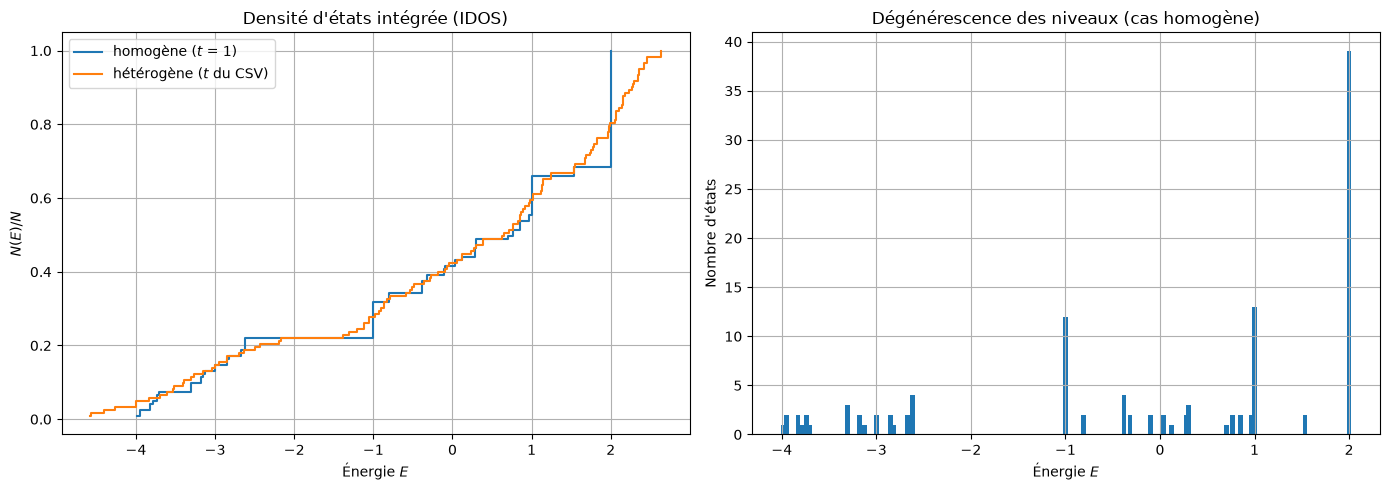

In [14]:
# 1. Même graphe avec toutes les liaisons à t_ : isole l'effet de l'hétérogénéité des t
model_homo = TBModel(Lattice(np.eye(2), coords, periodic_dirs=[]))
model_homo.set_onsite([0.0] * len(coords))
for e in edges:
    model_homo.set_hop(t_, int(e[0]), int(e[1]))
evals_homo = model_homo.solve_ham()

# 2. Escalier spectral : fraction des états d'énergie inférieure à E.
#    Les plateaux sont les trous du spectre, les marches verticales les niveaux dégénérés.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
frac = np.arange(1, len(coords) + 1) / len(coords)
ax1.step(np.sort(evals_homo), frac, where="post", label="homogène ($t$ = 1)")
ax1.step(np.sort(evals), frac, where="post", label="hétérogène ($t$ du CSV)")
ax1.set_title("Densité d'états intégrée (IDOS)")
ax1.set_xlabel("Énergie $E$")
ax1.set_ylabel("$N(E) / N$")
ax1.legend()
ax1.grid(True)

# 3. Dégénérescences : nombre d'états partageant le même niveau (à 1e-6 près)
levels, counts = np.unique(np.round(evals_homo, 6), return_counts=True)
ax2.bar(levels, counts, width=0.05)
ax2.set_title("Dégénérescence des niveaux (cas homogène)")
ax2.set_xlabel("Énergie $E$")
ax2.set_ylabel("Nombre d'états")
ax2.grid(True)

plt.tight_layout()
plt.show()

## Papillon de Hofstadter

Spectre en fonction du flux magnétique traversant le plus petit triangle. Sur le triangle régulier, toutes les boucles (petits et grands triangles) ont une aire multiple de la plus petite : le spectre est périodique en $\alpha$ et symétrique autour de $\alpha = 1/2$, avec une structure fractale de trous.
Sur le fractal courant, les aires et les $t$ irréguliers déphasent les boucles entre elles : la comparaison montre à quel point l'hétérogénéité détruit cette structure.

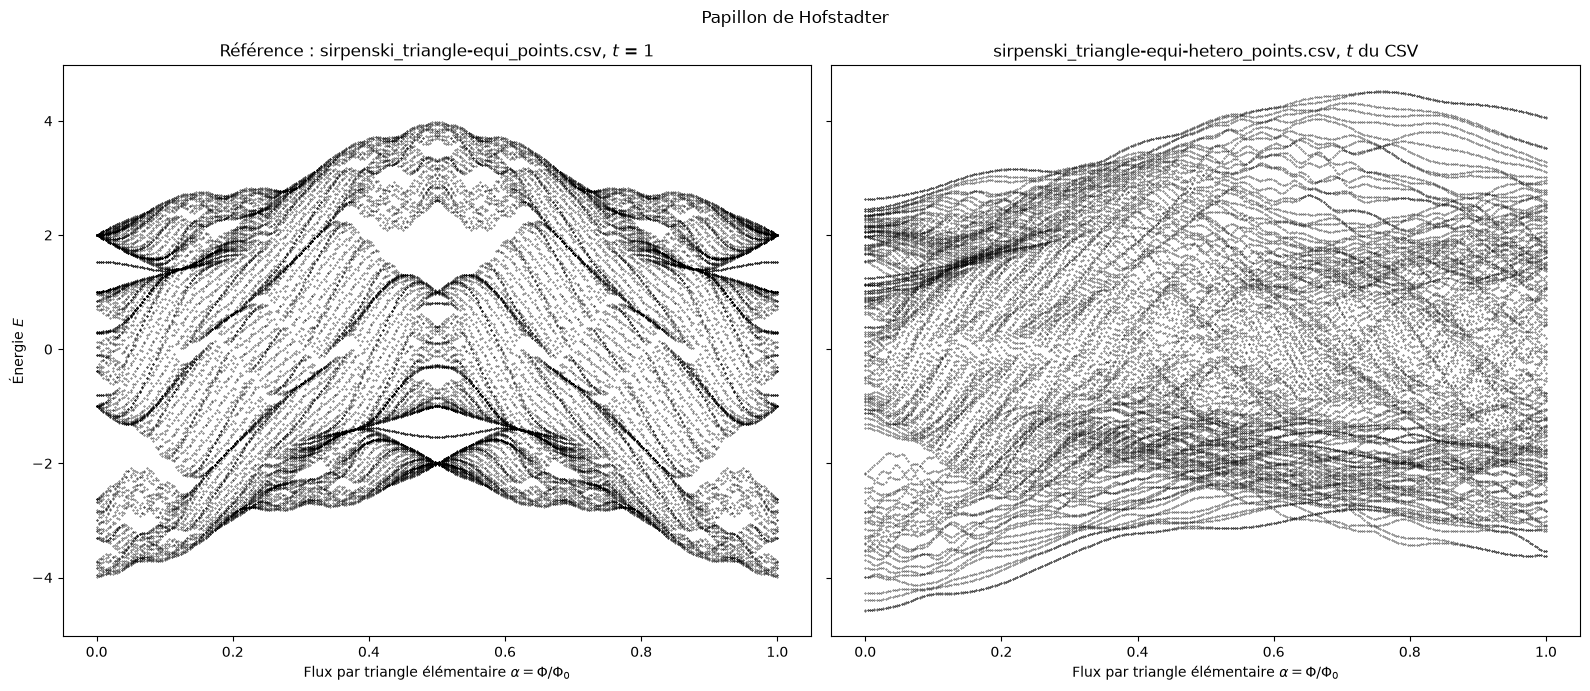

In [15]:
# Champ magnétique perpendiculaire via la substitution de Peierls (jauge de Landau A = (-B y, 0)) :
# t_ij -> t_ij * exp(i φ_ij), φ_ij = -2π B (y_i + y_j)/2 (x_j - x_i), B en quanta de flux par unité d'aire.
# α = flux à travers le plus petit triangle (aire calculée avec la longueur de liaison médiane).
def hofstadter(pts, ii, jj, amps, alphas):
    bond = np.median(np.linalg.norm(pts[ii] - pts[jj], axis=1))
    area0 = np.sqrt(3) / 4 * bond ** 2
    phase_unit = -2 * np.pi * (pts[ii, 1] + pts[jj, 1]) / 2 * (pts[jj, 0] - pts[ii, 0]) / area0
    spectra = []
    for alpha in alphas:
        H = np.zeros((len(pts), len(pts)), dtype=complex)
        H[ii, jj] = amps * np.exp(1j * alpha * phase_unit)
        H += H.conj().T
        spectra.append(np.linalg.eigvalsh(H))
    return np.array(spectra)

alphas = np.linspace(0, 1, 301)

# Référence : triangle régulier, toutes les liaisons à t_
ref_coords = pd.read_csv(ref_coords_path)[['x', 'y']].to_numpy()
ref_edges = pd.read_csv(ref_edges_path)[['i', 'j']].to_numpy()
spectra_ref = hofstadter(ref_coords, ref_edges[:, 0], ref_edges[:, 1],
                         t_ * np.ones(len(ref_edges)), alphas)

# Fractal courant (coordonnées et t du CSV)
ii = edges[:, 0].astype(int)
jj = edges[:, 1].astype(int)
amps = t_ * (edges[:, 2] if use_t else np.ones(len(edges)))
spectra_cur = hofstadter(coords, ii, jj, amps, alphas)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
ax1.plot(alphas, spectra_ref, "k.", markersize=0.6)
ax1.set_title(f"Référence : {ref_coords_path.split('/')[-1]}, $t$ = 1")
ax2.plot(alphas, spectra_cur, "k.", markersize=0.6)
ax2.set_title(f"{coords_path.split('/')[-1]}" + (", $t$ du CSV" if use_t else ", $t$ = 1"))
for ax in (ax1, ax2):
    ax.set_xlabel(r"Flux par triangle élémentaire $\alpha = \Phi / \Phi_0$")
ax1.set_ylabel("Énergie $E$")
fig.suptitle("Papillon de Hofstadter")
plt.tight_layout()
plt.show()

## Structure de bande

Un fractal fini n'a pas de vecteur d'onde $k$ : on le traite comme la maille élémentaire d'un super-réseau périodique.
Les mailles sont reliées par leurs trois coins (une liaison de longueur médiane entre deux coins voisins), puis on trace les bandes le long du chemin $\Gamma \to K \to M \to \Gamma$.
Les mailles ne communiquent que par 3 liaisons, donc la plupart des bandes sont plates : ce sont des états confinés dans la fractale. La largeur de bande indique les états qui atteignent les coins et traversent le réseau.

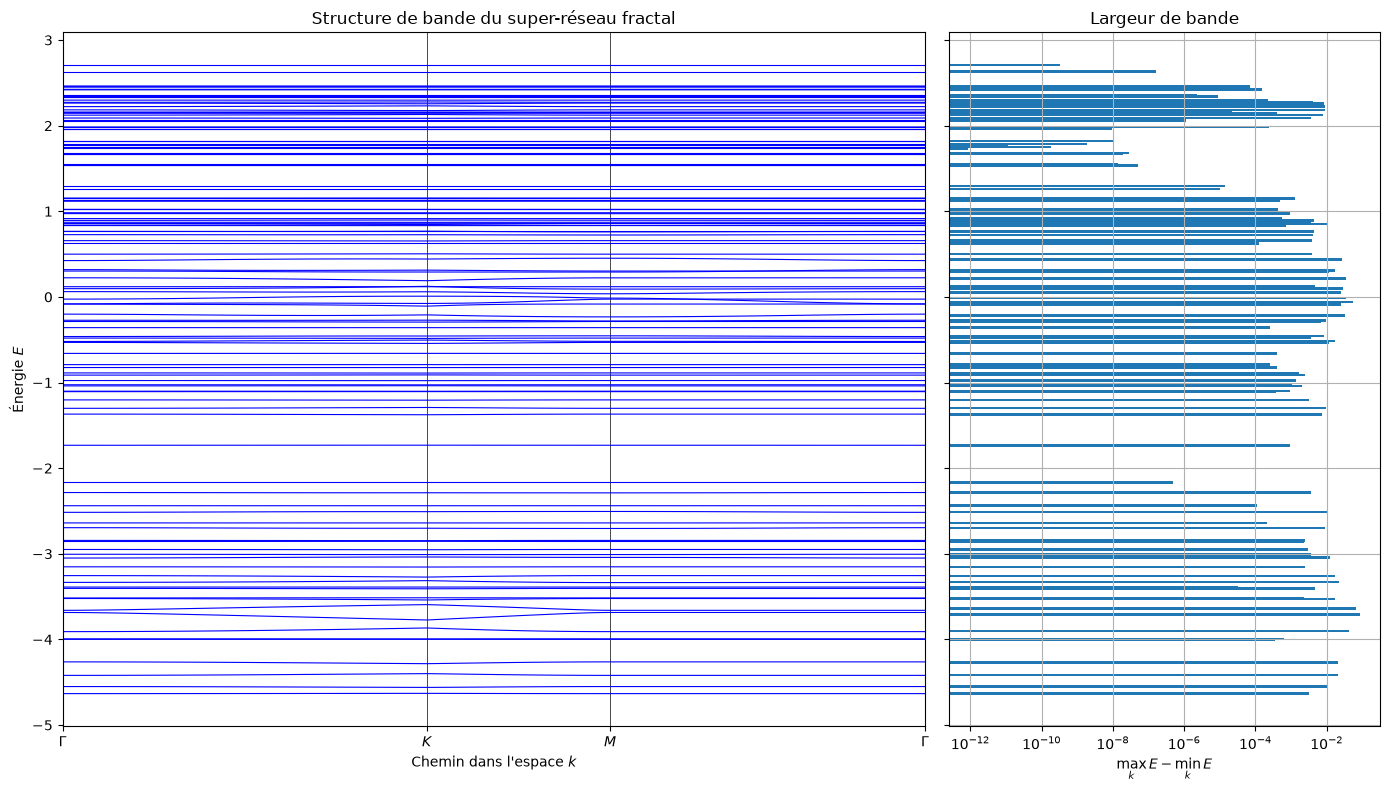

In [16]:
# 1. Coins du triangle : le plus loin du centre, puis le plus loin de ce coin,
#    puis le plus loin de la droite qui les relie
center = coords.mean(axis=0)
c0 = int(np.argmax(np.linalg.norm(coords - center, axis=1)))
c1 = int(np.argmax(np.linalg.norm(coords - coords[c0], axis=1)))
u = (coords[c1] - coords[c0]) / np.linalg.norm(coords[c1] - coords[c0])
rel = coords - coords[c0]
c2 = int(np.argmax(np.abs(rel[:, 0] * u[1] - rel[:, 1] * u[0])))
# pythtb impose une base directe
if np.linalg.det([coords[c1] - coords[c0], coords[c2] - coords[c0]]) < 0:
    c1, c2 = c2, c1

# 2. Vecteurs du super-réseau : côtés du triangle allongés d'une longueur de liaison
#    pour que les coins de deux mailles voisines soient reliés par une liaison
bond = np.median(np.linalg.norm(coords[edges[:, 0].astype(int)] - coords[edges[:, 1].astype(int)], axis=1))

def lat_vec(a, b):
    v = coords[b] - coords[a]
    return v * (1 + bond / np.linalg.norm(v))

lat_vecs = np.array([lat_vec(c0, c1), lat_vec(c0, c2)])

# 3. Modèle périodique (positions en coordonnées réduites)
orb_vecs = np.linalg.solve(lat_vecs.T, (coords - coords[c0]).T).T
lat_per = Lattice(lat_vecs, orb_vecs, periodic_dirs="all")
model_per = TBModel(lat_per)
model_per.set_onsite([0.0] * len(coords))

# liaisons internes à la maille
if use_t:
    for i, j, t in edges:
        model_per.set_hop(t_ * t, int(i), int(j), [0, 0])
else:
    for i, j in edges:
        model_per.set_hop(t_, int(i), int(j), [0, 0])

# liaisons entre mailles voisines (coin à coin)
model_per.set_hop(t_, c1, c0, [1, 0])
model_per.set_hop(t_, c2, c0, [0, 1])
model_per.set_hop(t_, c1, c2, [1, -1])

# 4. Bandes le long du chemin de haute symétrie du réseau triangulaire
k_nodes = [[0, 0], [2 / 3, 1 / 3], [1 / 2, 1 / 2], [0, 0]]
k_node_labels = (r"$\Gamma$", r"$K$", r"$M$", r"$\Gamma$")
nk = 121

k_path, k_dist, k_node_dist = model_per.k_path(k_nodes, nk)
evals_k = model_per.solve_ham(k_path)

# largeur de chaque bande : ~0 pour un état confiné dans la maille, grande s'il traverse les mailles
bandwidth = evals_k.max(axis=0) - evals_k.min(axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8), gridspec_kw={"width_ratios": [2, 1]}, sharey=True)
ax1.set_xlim(k_node_dist[0], k_node_dist[-1])
ax1.set_xticks(k_node_dist)
ax1.set_xticklabels(k_node_labels)
for d in k_node_dist:
    ax1.axvline(x=d, linewidth=0.5, color="k")
ax1.plot(k_dist, evals_k, c="b", linewidth=0.8)
ax1.set_title("Structure de bande du super-réseau fractal")
ax1.set_xlabel("Chemin dans l'espace $k$")
ax1.set_ylabel("Énergie $E$")

ax2.barh(evals_k.mean(axis=0), bandwidth, height=0.03)
ax2.set_xscale("log")
ax2.set_title("Largeur de bande")
ax2.set_xlabel("$\\max_k E - \\min_k E$")
ax2.grid(True)

plt.tight_layout()
plt.show()